In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
df = pd.read_csv("s.csv")

print(df.head())

print(df.shape)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)


In [4]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

corpus=[]

for i in range(len(df)):

    review = re.sub('[^a-zA-Z]',' ',df['review'][i])

    review = review.lower()

    review = review.split()

    review = [stemmer.stem(word)
              for word in review
              if word not in stop_words]

    review=' '.join(review)

    corpus.append(review)

print(corpus[:5])

['one review mention watch oz episod hook right exactli happen br br first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word br br call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda em citi home mani aryan muslim gangsta latino christian italian irish scuffl death stare dodgi deal shadi agreement never far away br br would say main appeal show due fact goe show dare forget pretti pictur paint mainstream audienc forget charm forget romanc oz mess around first episod ever saw struck nasti surreal say readi watch develop tast oz got accustom high level graphic violenc violenc injustic crook guard sold nickel inmat kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch oz may becom comfort uncomfort view that get touch d

In [6]:
df['sentiment']=df['sentiment'].replace({
    'positive':1,
    'negative':0
})

/tmp/ipykernel_3399/3244599736.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment']=df['sentiment'].replace({


In [7]:
tfidf=TfidfVectorizer(max_features=5000)

X=tfidf.fit_transform(corpus).toarray()

y=df['sentiment']

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model=LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [10]:
y_pred=model.predict(X_test)

In [11]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

print(classification_report(
    y_test,
    y_pred
))

Accuracy: 0.8862
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [12]:
cm=confusion_matrix(y_test,y_pred)

print(cm)

[[4319  642]
 [ 496 4543]]


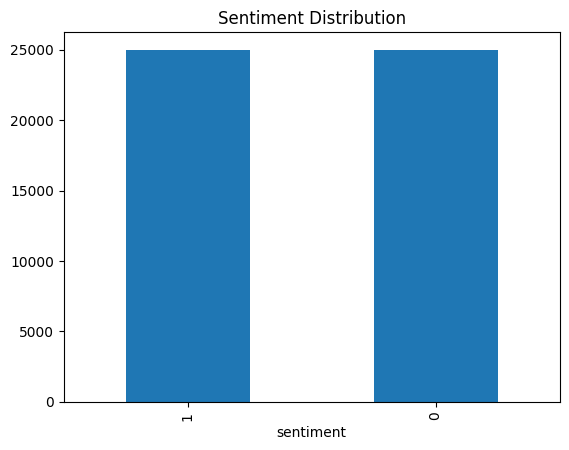

In [13]:
df['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Distribution")

plt.show()

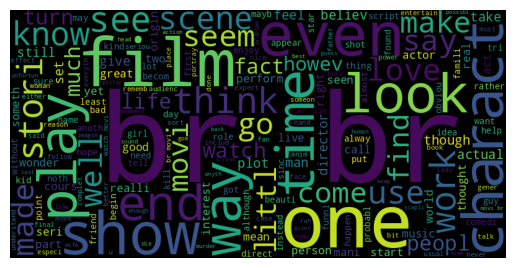

In [14]:
text=' '.join(corpus)

wordcloud=WordCloud(
    width=800,
    height=400
).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [15]:
new_review=["This movie was amazing and I loved it"]

new_review=tfidf.transform(
    new_review
)

prediction=model.predict(
    new_review
)

if prediction[0]==1:
    print("Positive")
else:
    print("Negative")

Positive
